# Generation of images with VAE

Now we try a new way to generate images with VAE. The goal of a VAE is to prevent our latent space from having holes or weirdly sparsed points on the space. 

To prevent that we use the **normal distribution**, which can be defined by:

$$ f(x|\mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}} $$

Here $f$ follows a normal distribution $\mathcal{N}(\mu, \sigma^2)$.

### Sampling and Training
In a VAE, when we take a vector in the latent space, we proceed to a **sampling**. We say: "ok, if we take a point in $z = \mu + \sigma \cdot \epsilon$ (where $\epsilon$ is a random noise), then we will have a point which is going to be like our vector". 

The goal of the training is to turn our latent space into a reduced centered normal law $$\mathcal{N}(0, 1)$$ (thanks to the **Kullback-Leibler divergence** loss).

By centering the distribution at $0$ with a standard deviation of $1$, we ensure that the latent space is compact, continuous, and easy to sample from for generating new, realistic images.

We can add that the latent space has more than one dimension. In a multidimensional space, the law is:

$$ f(x_1, \dots, x_k) = \frac{\exp\left(-\frac{1}{2}(x-\mu)^T \Sigma^{-1} (x-\mu)\right)}{\sqrt{(2\pi)^k | \Sigma |}} $$

In [1]:
import os
# Tensorflow trop bavard pour moi
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import yaml
from tensorflow import keras
import seaborn as sns

In [2]:
mnist = keras.datasets.mnist
(_, _), (x_test, y_test) = mnist.load_data()
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = np.pad(x_test, ((0,0), (2,2), (2,2), (0,0)), mode='constant')

### Sampling
Here the class sampling is exactly what we talked about when we said to take a point $z = \mu + \sigma \cdot \epsilon$. In our model, *z_mean* and *z_log_var* are trained dense layers of *latent_space_dim* size.

In [3]:
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch, dim = tf.shape(z_mean)[0], tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


with open("configs/vae_config.yaml", "r") as f:
    config = yaml.safe_load(f)
latent_dim = config['model_params']['latent_dim']
save_encoder = config['paths']['save_encoder']
save_decoder = config['paths']['save_decoder']

# Charger l'encodeur et le décodeur séparément
encoder = tf.keras.models.load_model(save_encoder, custom_objects={'Sampling': Sampling})
decoder = tf.keras.models.load_model(save_decoder)

### Checking the variation in the space
To see if we have a multidimension normal distribution we just check every dimension of the latent space, they are suppose to be more or like a normal distribution.

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step


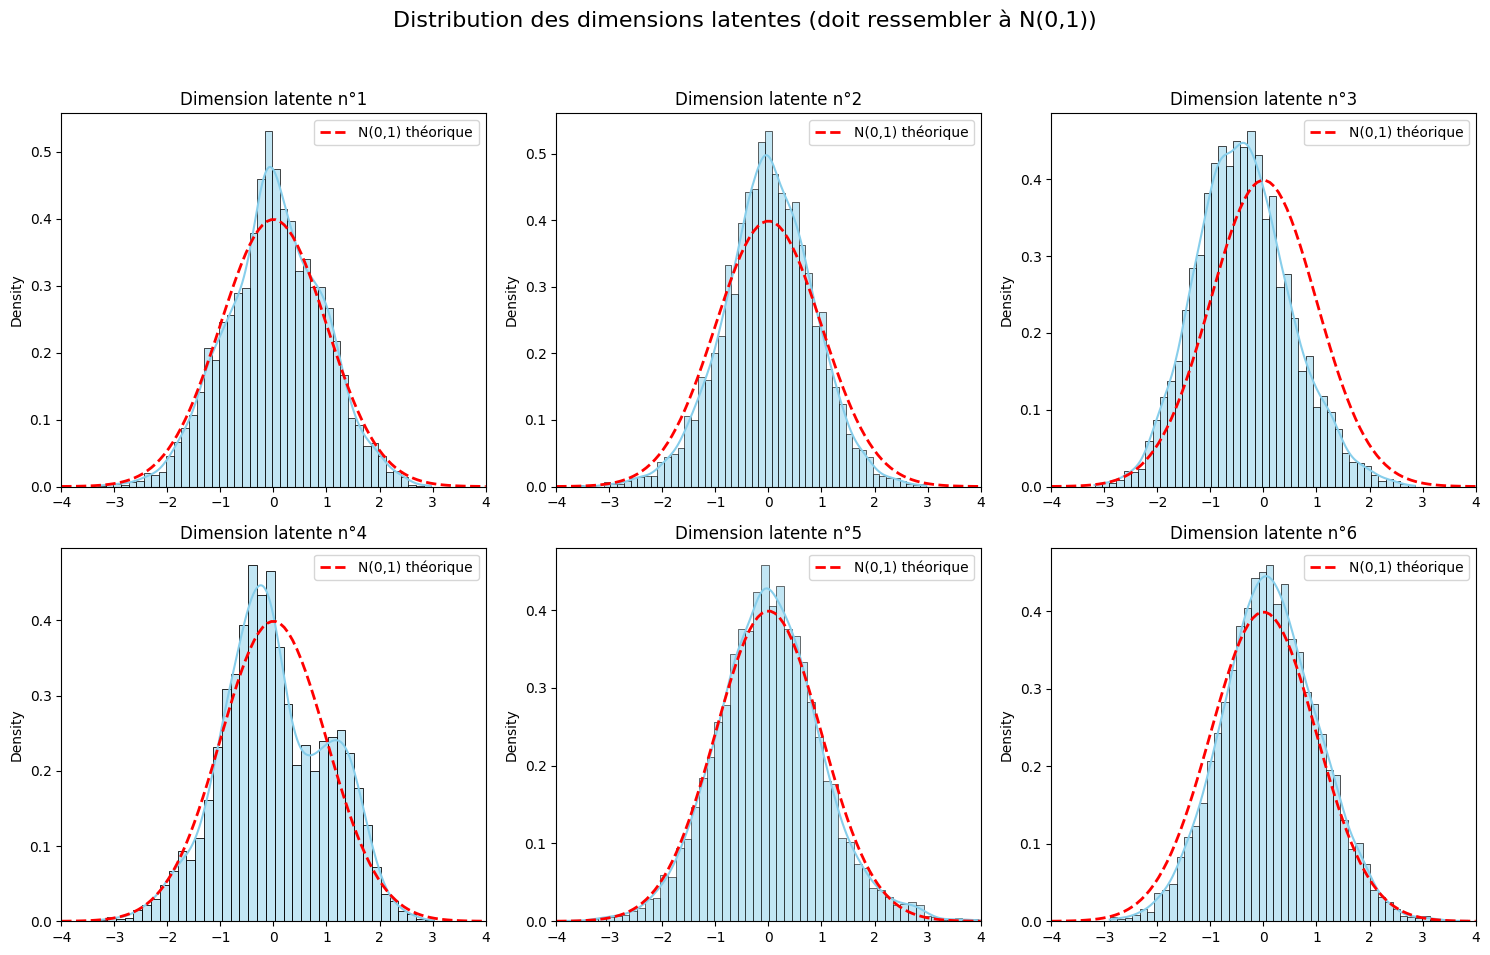

In [4]:
""" distribution  """

n_samples = 5000
z_mean, _, _ = encoder.predict(x_test[:n_samples])

num_dims_to_plot = min(6, latent_dim)

plt.figure(figsize=(15, 10))
plt.suptitle("Distribution des dimensions latentes (doit ressembler à N(0,1))", fontsize=16)

for i in range(num_dims_to_plot):
    plt.subplot(2, 3, i + 1)
    sns.histplot(z_mean[:, i], kde=True, color="skyblue", stat="density")
    
    x = np.linspace(-4, 4, 100)
    p = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * x**2)
    plt.plot(x, p, 'r--', lw=2, label='N(0,1) théorique')
    
    plt.title(f"Dimension latente n°{i+1}")
    plt.xlim(-4, 4)
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Checking trajectory in the space
here we check the trajectory between two numbers and two random vectors in the latent space. In both cases, we can say that we have coherent images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


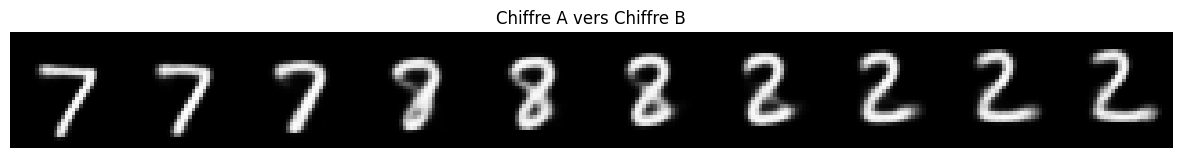

In [5]:
"""  trajet entre deux chiffres réels"""
res_A = encoder.predict(x_test[0:1])
res_B = encoder.predict(x_test[1:2])
code_A = res_A[0]
code_B = res_B[0]

steps = 10
grid = np.zeros((32, 32 * steps))

for i in range(steps):
    alpha = i / (steps - 1)
    inter_code = (1 - alpha) * code_A + alpha * code_B
    inter_img = decoder.predict(inter_code)
    grid[:, i*32:(i+1)*32] = inter_img.reshape(32, 32)

plt.figure(figsize=(15, 5))
plt.title("Chiffre A vers Chiffre B")
plt.imshow(grid, cmap='gray')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


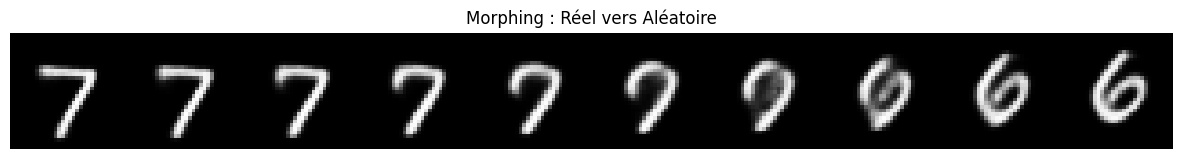

In [6]:

""" trajet vers random) """
code_A = encoder.predict(x_test[0:1])[0] 
code_B = np.random.normal(size=(1, latent_dim))

grid_random = np.zeros((32, 32 * steps))

for i in range(steps):
    alpha = i / (steps - 1)
    inter_code = (1 - alpha) * code_A + alpha * code_B
    inter_img = decoder.predict(inter_code)
    grid_random[:, i*32:(i+1)*32] = inter_img.reshape(32, 32)

plt.figure(figsize=(15, 5))
plt.title("Morphing : Réel vers Aléatoire")
plt.imshow(grid_random, cmap='gray')
plt.axis('off')
plt.show()